In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivam2503/diamonds/diamonds.csv


# 1. Load and inspect data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/shivam2503/diamonds/diamonds.csv')
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [4]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


# 2. Data Cleaning

## Step 1 - ID column drop

In [5]:
df = df.drop("Unnamed: 0", axis=1)

In [6]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Step 2 - Invalid values check

The invalid 0 values in x, y, z first need to be explicitly marked as NaN — this is a data-cleaning step, separate from deciding how to handle them. Once marked, check the count of affected rows to decide between dropping (if negligible) or imputing (if meaningful). Skew should only be checked afterward, and only if imputing was chosen — it determines mean vs. median, not the drop-vs-impute decision itself.

In [7]:
df.loc[df["x"] == 0, "x"] = np.nan
df.loc[df["y"] == 0, "y"] = np.nan
df.loc[df["z"] == 0, "z"] = np.nan
print(df[["x","y","z"]].isna().sum())

x     8
y     7
z    20
dtype: int64


Dropping rows with negligible invalid values (x, y, z's 0s here) is the simplest, safest choice — imputing would add unnecessary complexity for a fraction of a percent of the data.

In [8]:
df = df.dropna(subset=['x','y','z'])
print(df.shape)

(53920, 10)


In [9]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# 3. Univariate Analysis

## Step 1: On target column

In [10]:
print(df["price"].skew())

1.6183486340820077


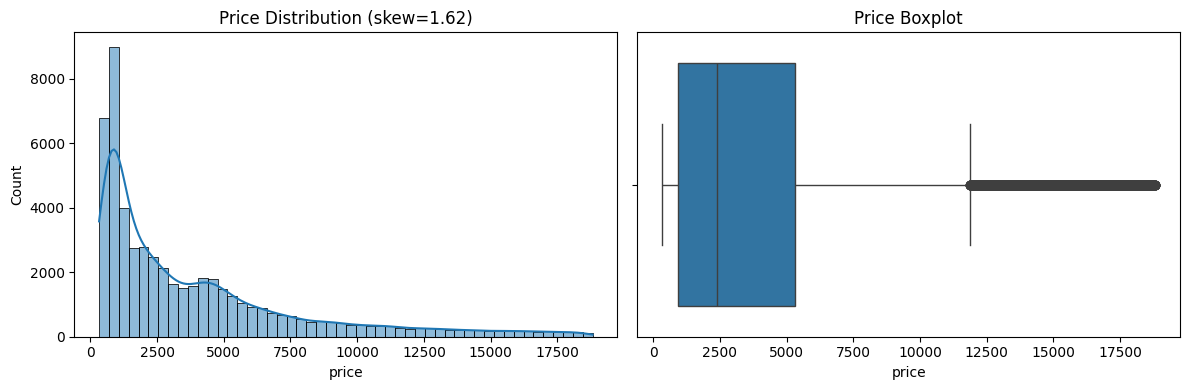

Skew: 1.6183486340820077
Kurtosis: 2.1783905464441284


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['price'], bins=50, kde= True, ax=ax[0])
ax[0].set_title(f"Price Distribution (skew={df['price'].skew():.2f})")

sns.boxplot(x=df['price'], ax=ax[1])
ax[1].set_title('Price Boxplot')

plt.tight_layout()
plt.show()

print("Skew:", df['price'].skew())
print("Kurtosis:", df['price'].kurt())

We can see its right skewed - so we can apply log transformation on price here

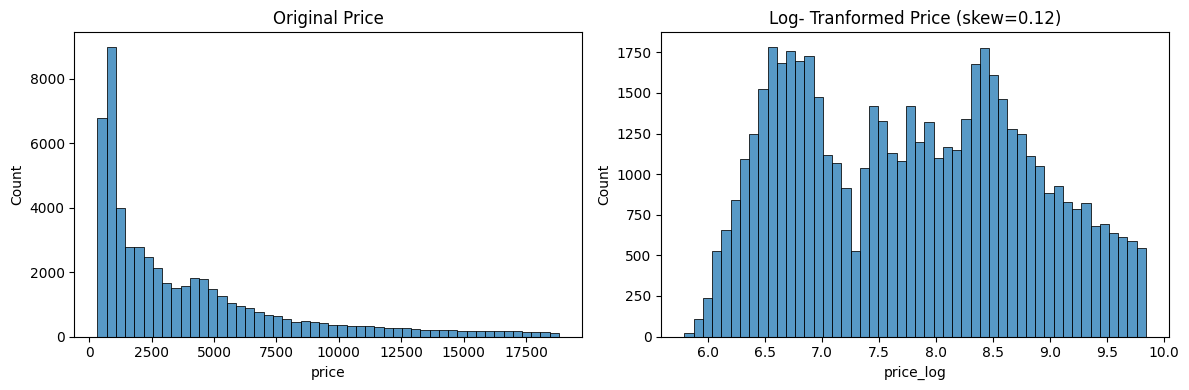

In [12]:
df['price_log'] = np.log1p(df['price'])

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['price'], bins=50, ax=ax[0])
ax[0].set_title('Original Price')

sns.histplot(df['price_log'], bins=50, ax=ax[1])
ax[1].set_title(f"Log- Tranformed Price (skew={df['price_log'].skew():.2f})")

plt.tight_layout()
plt.show()

## Step 2: On remaining numeric columns

In [13]:
numeric_cols = ['carat','depth','table','x','y','z']
print(df[numeric_cols].skew().sort_values(ascending=False))

y        2.462211
z        1.585490
carat    1.116207
table    0.796799
x        0.398348
depth   -0.081726
dtype: float64


In [14]:
print(df[["x","y","z"]].describe())

                  x             y             z
count  53920.000000  53920.000000  53920.000000
mean       5.731627      5.734887      3.540046
std        1.119423      1.140126      0.702530
min        3.730000      3.680000      1.070000
25%        4.710000      4.720000      2.910000
50%        5.700000      5.710000      3.530000
75%        6.540000      6.540000      4.040000
max       10.740000     58.900000     31.800000


Comparing the corrupted value against the OTHER two dimensions in the same row is exactly how you confirm a data-entry error rather than assume it — here, the impossible value is roughly 10x its expected magnitude, consistent with a decimal-point mistake, and the row's other two dimensions stay perfectly normal.

In [15]:
print(df[df["y"] > 15][["carat","x","y","z","price"]])
print(df[df["z"] > 15][["carat","x","y","z","price"]])

       carat     x     y     z  price
24067   2.00  8.09  58.9  8.06  12210
49189   0.51  5.15  31.8  5.12   2075
       carat     x     y     z  price
48410   0.51  5.12  5.15  31.8   1970


y=58.9mm and z=31.8mm are physically impossible for a diamond (typical range 3-10mm) — unlike a capped/winsorized "real but extreme" value, these are clear data-entry errors and warrant removal, not adjustment.

In [16]:
df = df[(df["y"] < 15) & (df["z"] < 15)]
print(df.shape)

print(df[["x","y","z"]].skew())

(53917, 11)
x    0.398282
y    0.392737
z    0.393823
dtype: float64


Just 3 corrupted rows out of ~54,000 were enough to make y's skew look 6x worse than it actually was — a small number of data-entry errors can badly distort summary statistics like skew, which is exactly why investigating "surprising" numbers (rather than accepting them) matters so much.

## Step 3 -  Univariate Analysis on Categorical column balance check

Checking the frequency distribution of each categorical column to see if any single category dominates — a heavily imbalanced column carries little useful signal for the model, so this scan flags potential near-constant columns before moving on to bivariate analysis.

In [17]:
for col in ['cut', 'color', 'clarity']:
    print(col, ':', df[col].nunique(), 'unique values')
    print(df[col].value_counts(normalize=True))
    print()

cut : 5 unique values
cut
Ideal        0.399633
Premium      0.255559
Very Good    0.224048
Good         0.090918
Fair         0.029842
Name: proportion, dtype: float64

color : 7 unique values
color
G    0.209285
E    0.181668
F    0.176902
H    0.153885
D    0.125638
I    0.100543
J    0.052080
Name: proportion, dtype: float64

clarity : 8 unique values
clarity
SI1     0.242280
VS2     0.227275
SI2     0.170336
VS1     0.151492
VVS2    0.093959
VVS1    0.067771
IF      0.033199
I1      0.013688
Name: proportion, dtype: float64



All three categorical columns show healthy distribution across their categories, with no single value dominating (99%), none of these are near-zero-variance drop candidates.

# 4. Multivariate Analysis

## Step 1. Bivariate Analysis - Numeric Features vs price correlation

In [18]:
numeric_cols = ['carat', 'depth', 'table', 'x','y','z']
correlations = df[numeric_cols + ['price', 'price_log']].corr()[["price","price_log"]]
print(correlations)

              price  price_log
carat      0.921586   0.920305
depth     -0.010653   0.000955
table      0.127241   0.158243
x          0.887221   0.960739
y          0.888818   0.961530
z          0.882107   0.956637
price      1.000000   0.895885
price_log  0.895885   1.000000


x, y, z show a dramatically stronger correlation with price_log (0.96) than raw price (0.88) — concrete proof that the price-size relationship is naturally multiplicative, and log-transforming the target both fixes skew AND reveals a relationship Pearson correlation was missing on the raw scale.

## Early indication for feature selection

Strong predictors - carat, y, x, z

Weak/neglible predictors - table(0.158) , depth(0.001)

## Step 2 : Carat vs x,y,z redundancy check

Checking whether carat, x, y, and z are highly correlated with EACH OTHER (not just with the target) — since all four already showed strong correlation with price_log individually, this step confirms whether they're carrying largely the same information, which would make keeping all four redundant rather than helpful.

In [19]:
print(df[["carat","x","y","z"]].corr())

          carat         x         y         z
carat  1.000000  0.977778  0.976860  0.976478
x      0.977778  1.000000  0.998657  0.991077
y      0.976860  0.998657  1.000000  0.990730
z      0.976478  0.991077  0.990730  1.000000


Correlations of 0.976-0.999 between carat, x, y, z indicate near-perfect redundancy — keeping all four would be almost equivalent to giving the model the same size information four separate times, exactly the kind of severe multicollinearity VIF flags as inf.

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_cols = ['carat', 'depth', 'table', 'x', 'y','z']

X = df[num_cols].dropna()
vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    index=num_cols
)
print(vif.sort_values(ascending=False))

x        11748.048131
y        10507.121772
z         3222.132974
depth      913.065454
table      686.542245
carat       91.492418
dtype: float64


*depth's high VIF despite near-zero correlation with price is exactly the scenario VIF exists to catch: it's a near-exact mathematical ratio of x, y, z (depth = z/((x+y)/2)100), so even though it doesn't correlate with the target, it's almost entirely "explainable" by the other kept features — pairwise correlation with price alone would have missed this.

In [21]:
print(df.columns.tolist())

['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z', 'price_log']


In [22]:
df = df.drop(columns=["x","y","z"])

In [23]:
df.head()

,carat,cut,color,clarity,depth,table,price,price_log
0,0.23,Ideal,E,SI2,61.5,55.0,326,5.789960
1,0.21,Premium,E,SI1,59.8,61.0,326,5.789960
2,0.23,Good,E,VS1,56.9,65.0,327,5.793014
3,0.29,Premium,I,VS2,62.4,58.0,334,5.814131
4,0.31,Good,J,SI2,63.3,58.0,335,5.817111


In [24]:
num_cols_final = ["carat","depth","table"]
X = df[num_cols_final].dropna()

vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    index=num_cols_final
)
print(vif.sort_values(ascending=False))

table    397.043690
depth    389.562983
carat      3.929133
dtype: float64


In [25]:
df = df.drop(columns=["depth"])

In [26]:
print(df.columns.tolist())

['carat', 'cut', 'color', 'clarity', 'table', 'price', 'price_log']


In [27]:
from statsmodels.tools.tools import add_constant

num_cols_final = ["carat","table"]
X = df[num_cols_final].dropna()
X_with_const = add_constant(X)

vif = pd.Series(
    [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])],
    index=X_with_const.columns
)
print(vif)

const    671.687303
carat      1.034121
table      1.034121
dtype: float64


carat and table now show VIF ≈ 1.03 — essentially no multicollinearity remaining. The const row's high VIF is expected and always ignored when interpreting results; only the real feature rows matter.

✅ x, y, z → dropped (redundant with carat)
✅ depth → dropped (near-zero target correlation)
✅ table → kept (VIF confirms no redundancy with carat)
✅ carat → kept (strongest, cleanest size-proxy)

# Train-test split

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["price", "price_log"])
y = df["price_log"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Encoding and Scaling

ColumnTransformer bundles all your encoding/scaling logic into ONE reusable object — combined with Pipeline, the entire preprocessing + model becomes a single unit that can be saved, reused, and deployed without repeating manual fit/transform steps for every column group.

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

cut_order = ['Fair','Good','Very Good','Premium','Ideal']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]

preprocessor = ColumnTransformer(transformers=[
    ("ordinal", OrdinalEncoder(categories=[cut_order, color_order, clarity_order]),
     ["cut", "color", "clarity"]),
    ("scale", StandardScaler(), ["carat", "table"])
])

One object now holds the entire preprocessing logic — three ordinal columns with their own custom orders, and two numeric columns to scale — replacing five separate manual fit/transform blocks with a single definition.

# Pipeline

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

In [31]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Fair',
                                                                              'Good',
                                                                              'Very '
                                                                              'Good',
                                                                              'Premium',
                                                                              'Ideal'],
                                                                             ['J',
                                                                              'I',
                                                                              'H',
                                                                              'G',
                                                                              'F',
                                                                              'E',
                                                                              'D'],
                                                                             ['I1',
                                                                              'SI2',
                                                                              'SI1',
                                                                              'VS2',
                                                                              'VS1',
                                                                              'VVS2',
                                                                              'VVS1',
                                                                              'IF']]),
                                                  ['cut', 'color', 'clarity']),
                                                 ('scale', StandardScaler(),
                                                  ['carat', 'table'])])),
                ('model', LinearRegression())])

# Predict and evaluate

In [32]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

predictions_log = full_pipeline.predict(X_test)
predictions_real = np.expm1(predictions_log)
y_test_real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
r2 = r2_score(y_test_real, predictions_real)
print(f"RMSE: {rmse:.2f}, R²: {r2:.4f}")

RMSE: 38476.65, R²: -92.9321


why R² came out so extreme (-92.93):

The model is actually performing well in log-space (R² = 0.88), but one specific test row — a 4.5-carat diamond with the worst possible cut, color, and clarity — sits about 7.9 standard deviations away from the typical carat value in training data. Linear Regression, unlike tree-based models, always extrapolates linearly rather than capping predictions to the training range. For this extreme, rare feature combination, it extrapolated a predicted log-price of 15.19 versus an actual log-price of 9.83 — a modest-looking error in log-space. But reversing the log-transform with expm1() is an exponential operation, so that log-space error explodes into a real-dollar error of roughly $3.9 million on a single row. Since RMSE/R² are both built on squared errors, this one catastrophic row is enough to drag the entire metric to an extreme negative value, even though the vast majority of predictions are reasonable.

In [33]:
print("R² (log-space):", r2_score(y_test, predictions_log))

R² (log-space): 0.8803726502704319


The model was trained to minimize error in log-space — that's the actual optimization target, and the actual, honest measure of how well the model learned the underlying pattern. Log-space R² (0.88) reflects that genuine model quality. Real-dollar R², by contrast, isn't measuring "how good is the model" so much as "how badly does one exponential back-transform amplify a handful of extrapolation errors" — a different, and in this case misleading, question. Reporting log-space R² alongside the real-dollar metric gives a truthful picture instead of letting one exploded number imply the model is catastrophically broken.

In [34]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test_real, predictions_real))

2020.3634082353633


RMSE squares errors before averaging, so it punishes large errors disproportionately — exactly the property that let one $3.9M-off prediction dominate the entire metric. MAE treats every error with equal weight (no squaring), so a handful of extreme extrapolation cases can't single-handedly distort the number the way they do with RMSE. MAE gives a far more representative picture of "how far off is a typical prediction," which is usually the more useful, more stakeholder-friendly number to report anyway.

In [35]:
print(df["price"].median())

2401.0


In [36]:
print(df["carat"].quantile([0.99, 0.995, 0.999]))

0.990    2.18000
0.995    2.31000
0.999    2.67084
Name: carat, dtype: float64


# Cross-val

In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring="r2")
print(f"CV R² Mean: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")

CV R² Mean: 0.8802, Std: 0.0049


In [38]:
threshold = df["carat"].quantile(0.995)
df_capped = df[df["carat"] < threshold].copy()
print(df_capped.shape)

(53638, 7)


In [39]:
X = df_capped.drop(columns=["price", "price_log"])
y = df_capped["price_log"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_pipeline.fit(X_train, y_train)
predictions_log = full_pipeline.predict(X_test)
predictions_real = np.expm1(predictions_log)
y_test_real = np.expm1(y_test)

rmse_capped = np.sqrt(mean_squared_error(y_test_real, predictions_real))
r2_capped = r2_score(y_test_real, predictions_real)
mae_capped = mean_absolute_error(y_test_real, predictions_real)

print(f"RMSE: {rmse_capped:.2f}, R²: {r2_capped:.4f}, MAE: {mae_capped:.2f}")

RMSE: 3979.91, R²: -0.0634, MAE: 1428.74


We only log-transformed the target (price), not the carat feature — but diamond pricing follows a power-law relationship (log(price) linear in log(carat)), not an exponential one (log(price) linear in raw carat). This mismatch causes the model to systematically overpredict for large diamonds, since exponential growth vastly outpaces power-law growth at high values.